In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# ── Models ─────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.naive_bayes import GaussianNB          # regression via binning trick
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor


##  Load the Dataset

In [2]:
df = pd.read_csv('retail_sales_dataset.csv')
print('Rows and Columns:', df.shape)
df.head()

Rows and Columns: (1000, 9)


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [5]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
 9   Gender_enc        1000 non-null   int64 
 10  Category_enc      1000 non-null   int64 
dtypes: int64(7), object(4)
memory usage: 86.1+ KB


##Data Preprocessing

###  Check Missing Values

In [34]:
print(df.isnull().sum())

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
Gender_enc          0
Category_enc        0
dtype: int64


### Check Duplicates

In [35]:
print('Duplicate rows:', df.duplicated().sum())
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print('Clean shape:', df.shape)

Duplicate rows: 0
Clean shape: (1000, 11)


### Check Outliers with Box Plots

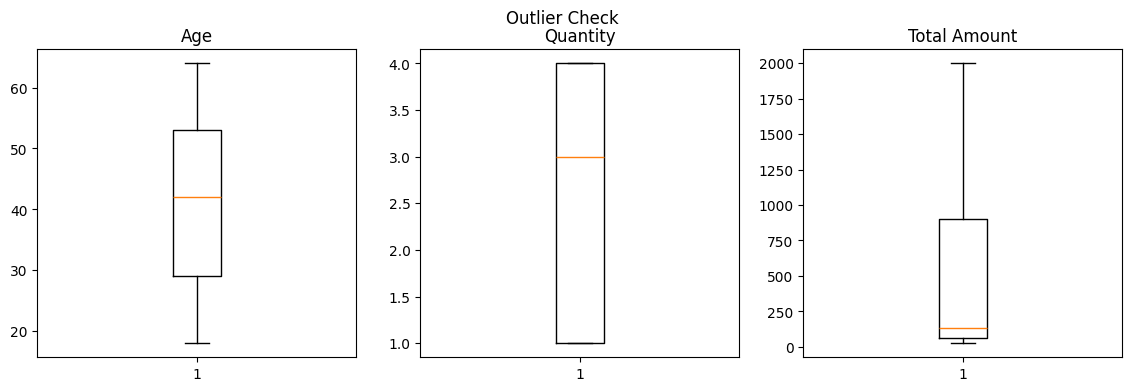

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['Age', 'Quantity', 'Total Amount']):
    ax.boxplot(df[col])
    ax.set_title(col)
plt.suptitle('Outlier Check')
plt.show()
# We keep outliers — large purchases are real business events

###  Encode Categorical Columns

In [37]:
le = LabelEncoder()
df['Gender_enc']   = le.fit_transform(df['Gender'])
df['Category_enc'] = le.fit_transform(df['Product Category'])
print(df[['Gender','Gender_enc','Product Category','Category_enc']].head())

   Gender  Gender_enc Product Category  Category_enc
0    Male           1           Beauty             0
1  Female           0         Clothing             1
2    Male           1      Electronics             2
3    Male           1         Clothing             1
4    Male           1           Beauty             0


## Exploratory Data Analysis (EDA)

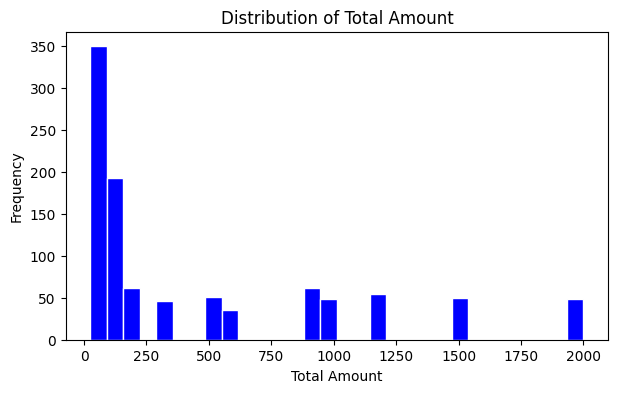

In [38]:
plt.figure(figsize=(7, 4))
plt.hist(df['Total Amount'], bins=30, color='blue', edgecolor='white')
plt.title('Distribution of Total Amount')
plt.xlabel('Total Amount')
plt.ylabel('Frequency')
plt.show()

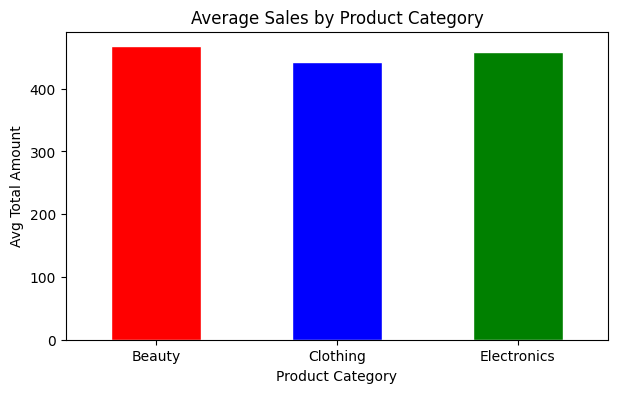

In [14]:
cat_avg = df.groupby('Product Category')['Total Amount'].mean()
plt.figure(figsize=(7, 4))
cat_avg.plot(kind='bar', color=['Red','Blue','Green'], edgecolor='white')
plt.title('Average Sales by Product Category')
plt.ylabel('Avg Total Amount')
plt.xlabel('Product Category')
plt.xticks(rotation=0)
plt.show()

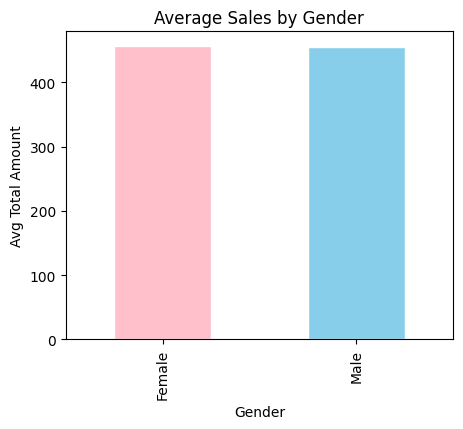

In [15]:
gender_avg = df.groupby('Gender')['Total Amount'].mean()
plt.figure(figsize=(5, 4))
gender_avg.plot(kind='bar', color=['Pink','Skyblue'], edgecolor='white')
plt.title('Average Sales by Gender')
plt.ylabel('Avg Total Amount')
plt.xlabel('Gender')
plt.show()

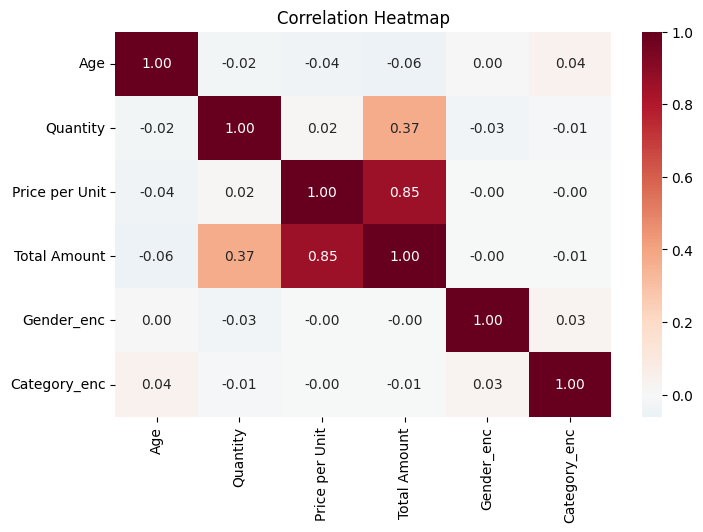

In [16]:
cols = ['Age','Quantity','Price per Unit','Total Amount','Gender_enc','Category_enc']
plt.figure(figsize=(8, 5))
sns.heatmap(df[cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Correlation Heatmap')
plt.show()

## Feature Selection & Train/Test Split

In [39]:
features = ['Age', 'Quantity', 'Price per Unit', 'Gender_enc', 'Category_enc']
X = df[features]
y = df['Total Amount']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Training samples:', len(X_train))
print('Testing  samples:', len(X_test))

Training samples: 800
Testing  samples: 200


## Train  Models

| # | Model | Notes |
|---|-------|-------|
| 1 | Linear Regression | Baseline straight-line model |
| 2 | Decision Tree | Rule-based splits |
| 3 | Random Forest | Ensemble of 100 trees |
| 4 | **Gradient Boosting** | Builds trees sequentially to fix errors |
| 5 | **XGBoost** | Faster, regularised gradient boosting |
| 6 | **Support Vector Machine (SVR)** | Finds optimal margin hyperplane |
| 7 | **K-Nearest Neighbors (KNN)** | Predicts from k nearest data points |

In [40]:
# Scale features — required for SVR and KNN
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print('Scaling done!')

Scaling done!


In [43]:
# ── Model 1: Linear Regression ───────────────────────────────────
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print('Linear Regression done!')

Linear Regression done!


In [44]:
# ── Model 2: Decision Tree ───────────────────────────────────────
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print(' Decision Tree done!')

 Decision Tree done!


In [45]:
# ── Model 3: Random Forest ───────────────────────────────────────
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print('Random Forest done!')

Random Forest done!


In [46]:
# ── Model 4: Gradient Boosting ───────────────────────────────────

gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                max_depth=4, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
print(' Gradient Boosting done!')

 Gradient Boosting done!


In [47]:
# ── Model 5: XGBoost ─────────────────────────────────────────────

xgb = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=4,
                    subsample=0.8, colsample_bytree=0.8,
                    random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print('XGBoost done!')

XGBoost done!


In [48]:
# ── Model 6: Support Vector Regression (SVR) ─────────────────────

svr = SVR(kernel='rbf', C=1000, epsilon=50)
svr.fit(X_train_sc, y_train)       # uses scaled data
y_pred_svr = svr.predict(X_test_sc)
print('Support Vector Regression done!')

Support Vector Regression done!


In [49]:
# ── Model 7: K-Nearest Neighbors (KNN) ───────────────────────────

knn = KNeighborsRegressor(n_neighbors=10, weights='distance')
knn.fit(X_train_sc, y_train)       # uses scaled data
y_pred_knn = knn.predict(X_test_sc)
print('K-Nearest Neighbors done!')

K-Nearest Neighbors done!


## Model Optimization (Random Forest)

In [42]:
param_grid = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [None, 10, 20],
    'min_samples_split': [2, 5]
}
grid = GridSearchCV(RandomForestRegressor(random_state=42),
                    param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)
best_rf = grid.best_estimator_
y_pred_best = best_rf.predict(X_test)
print('Best settings:', grid.best_params_)
print('Best R²:', round(grid.best_score_, 4))

Best settings: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best R²: 1.0


##  Model Evaluation & Performance Comparison

- **MAE** = Average prediction error in dollars (lower = better)
- **RMSE** = Error that penalises large mistakes more (lower = better)
- **R²** = How well the model explains the data (closer to 1.0 = better)
- **Accuracy %** = R² expressed as a percentage

In [50]:
def get_metrics(name, y_true, y_pred):
    r2  = round(r2_score(y_true, y_pred), 4)
    return {
        'Model'      : name,
        'MAE'        : round(mean_absolute_error(y_true, y_pred), 2),
        'RMSE'       : round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
        'R²'         : r2,
        'Accuracy %' : round(max(r2, 0) * 100, 2)
    }

results = pd.DataFrame([
    get_metrics('Linear Regression',    y_test, y_pred_lr),
    get_metrics('Decision Tree',        y_test, y_pred_dt),
    get_metrics('Random Forest',        y_test, y_pred_rf),
    get_metrics('RF Optimized',         y_test, y_pred_best),
    get_metrics('Gradient Boosting',    y_test, y_pred_gb),
    get_metrics('XGBoost',              y_test, y_pred_xgb),
    get_metrics('SVR',                  y_test, y_pred_svr),
    get_metrics('KNN',                  y_test, y_pred_knn),
])

results_sorted = results.sort_values('R²', ascending=False).reset_index(drop=True)
print(results_sorted.to_string(index=False))

            Model    MAE   RMSE     R²  Accuracy %
    Decision Tree   0.00   0.00 1.0000      100.00
    Random Forest   0.00   0.00 1.0000      100.00
     RF Optimized   0.00   0.00 1.0000      100.00
Gradient Boosting   0.00   0.01 1.0000      100.00
          XGBoost   7.68  12.72 0.9994       99.94
              SVR  28.73  34.09 0.9960       99.60
              KNN  48.95  76.44 0.9800       98.00
Linear Regression 173.03 204.65 0.8569       85.69


### Accuracy Comparison Chart

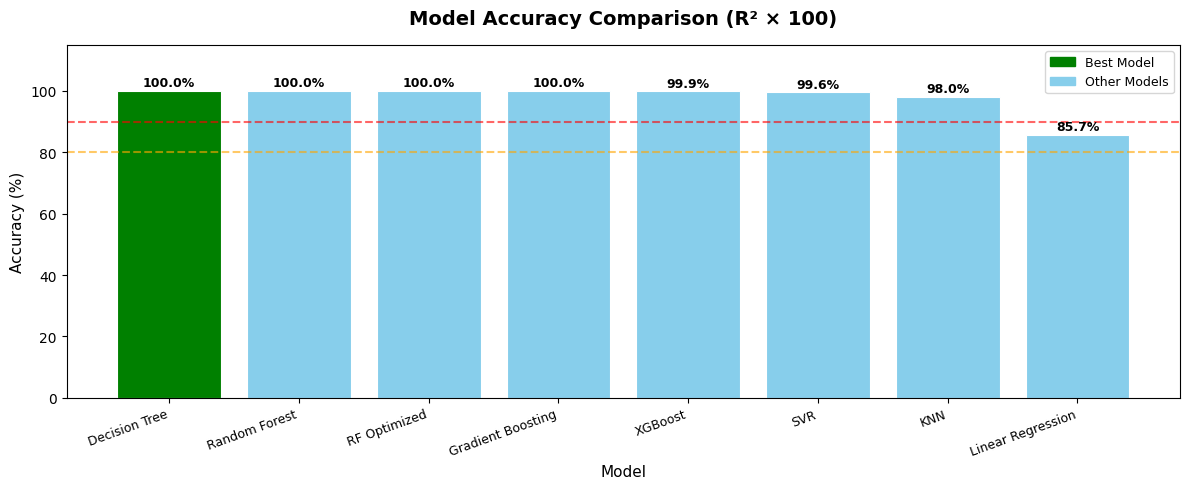

Chart saved as accuracy_comparison.png


In [59]:
palette = ['Green' if i == 0 else 'skyblue'
           for i in range(len(results_sorted))]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(results_sorted['Model'], results_sorted['Accuracy %'],
              color=palette, edgecolor='white', linewidth=0.8)

# Add value labels on top of bars
for bar, val in zip(bars, results_sorted['Accuracy %']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Model Accuracy Comparison (R² × 100)', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_xlabel('Model', fontsize=11)
ax.set_ylim(0, 115)
ax.set_xticks(range(len(results_sorted)))
ax.set_xticklabels(results_sorted['Model'], rotation=20, ha='right', fontsize=9)
ax.axhline(y=80, color='orange', linestyle='--', alpha=0.6, label='80% threshold')
ax.axhline(y=90, color='red',    linestyle='--', alpha=0.6, label='90% threshold')
ax.legend(fontsize=9)

best_patch  = mpatches.Patch(color='Green',   label='Best Model')
other_patch = mpatches.Patch(color='SkyBlue', label='Other Models')
ax.legend(handles=[best_patch, other_patch], loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as accuracy_comparison.png')

### Full Metrics Comparison (MAE, RMSE, R²)

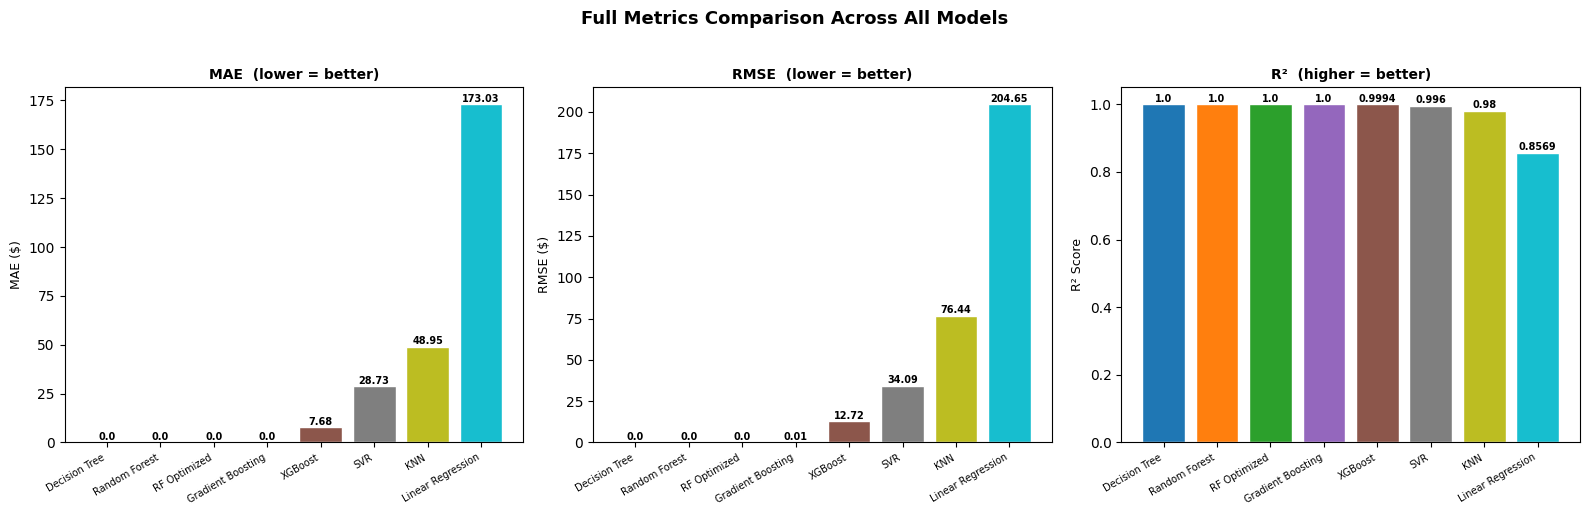

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(results_sorted)))

metrics = [('MAE',  'lower = better',  r'MAE ($)'),
           ('RMSE', 'lower = better',  r'RMSE ($)'),
           ('R²',   'higher = better', 'R² Score')]

for ax, (metric, note, ylabel) in zip(axes, metrics):
    bars = ax.bar(results_sorted['Model'], results_sorted[metric],
                  color=colors, edgecolor='white')
    for bar, val in zip(bars, results_sorted[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002 * results_sorted[metric].max(),
                f'{val}', ha='center', va='bottom', fontsize=7, fontweight='bold')
    ax.set_title(f'{metric}  ({note})', fontsize=10, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_xticks(range(len(results_sorted)))
    ax.set_xticklabels(results_sorted['Model'], rotation=30, ha='right', fontsize=7)

plt.suptitle('Full Metrics Comparison Across All Models', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('full_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

###  Actual vs Predicted — Best Model

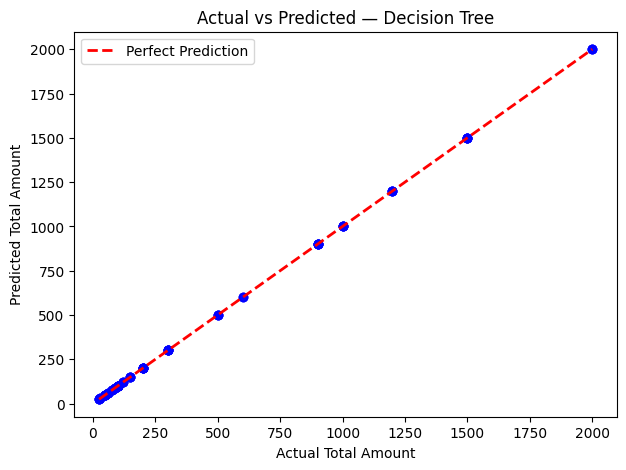

In [60]:
best_name = results_sorted.iloc[0]['Model']
pred_map  = {
    'Linear Regression': y_pred_lr,
    'Decision Tree':     y_pred_dt,
    'Random Forest':     y_pred_rf,
    'RF Optimized':      y_pred_best,
    'Gradient Boosting': y_pred_gb,
    'XGBoost':           y_pred_xgb,
    'SVR':               y_pred_svr,
    'KNN':               y_pred_knn,
}
y_pred_winner = pred_map[best_name]

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_winner, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Total Amount')
plt.ylabel('Predicted Total Amount')
plt.title(f'Actual vs Predicted — {best_name}')
plt.legend()
plt.show()

### Feature Importance (Best Tree-Based Model)

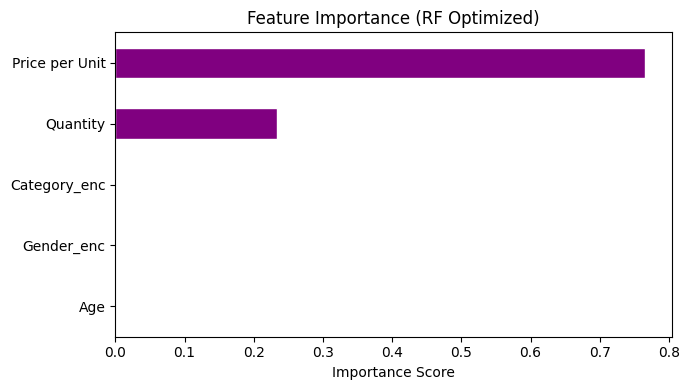

In [57]:
feat_imp = pd.Series(best_rf.feature_importances_, index=features).sort_values()

plt.figure(figsize=(7, 4))
feat_imp.plot(kind='barh', color='Purple', edgecolor='white')
plt.title('Feature Importance (RF Optimized)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

##  Model Explanations

### Why each new model was added:

#### 4. Gradient Boosting
Trains trees **sequentially** — each new tree corrects the errors of the previous one. It is slower than Random Forest but often more accurate because it directly optimises prediction error at every step.

#### 5. XGBoost (Extreme Gradient Boosting)
A **faster, regularised** version of Gradient Boosting. It adds L1 and L2 regularisation terms to prevent overfitting, making it very popular in data science competitions. Column and row subsampling also help generalisation.

#### 6. Support Vector Regression (SVR)
Finds the best-fit hyperplane within an **epsilon-insensitive tube** around the data. Uses the **RBF kernel** to capture non-linear patterns. Requires feature scaling. Good when the feature space is high-dimensional.

#### 7. K-Nearest Neighbors (KNN)
Makes predictions by **averaging the target values of the k closest training examples** in feature space. Non-parametric — it memorises the training data rather than learning a model equation. Sensitive to scale, so StandardScaler is applied first.



##  Business Insights & Recommendations

### What the models tell us:
1. **Price per Unit** is the strongest predictor — higher-priced items drive the most revenue
2. **Quantity** is 2nd most important — bulk purchases boost transaction value
3. **Electronics** has the highest average transaction value — prioritise stock during Q4
4. **Age** and **Gender** have low importance — products appeal equally across all groups

### Recommendations:
- Offer **bundle discounts** to increase quantity per transaction
- Run **Electronics promotions** in Q4 (Oct–Dec) to boost peak season revenue
- Use the winning model to **forecast monthly revenue** and plan inventory

### Limitations:
- Only ~1,000 records — more data = better accuracy
- No discount or promotion data included
- Location/store information not available

In [32]:
winner = results_sorted.iloc[0]
print('=================================================')
print(f'  BEST MODEL: {winner["Model"]}')
print('=================================================')
print(f'  Accuracy: {winner["Accuracy %"]}%')
print(f'  R²      : {winner["R²"]}  (explains {winner["Accuracy %"]}% of variance)')
print(f'  MAE     : ${winner["MAE"]}  (avg error in dollars)')
print(f'  RMSE    : ${winner["RMSE"]}')
print('=================================================')
print()
print('All models ranked by Accuracy:')
print(results_sorted[['Model','Accuracy %','R²','MAE','RMSE']].to_string(index=False))

  BEST MODEL: Decision Tree
  Accuracy: 100.0%
  R²      : 1.0  (explains 100.0% of variance)
  MAE     : $0.0  (avg error in dollars)
  RMSE    : $0.0

All models ranked by Accuracy:
            Model  Accuracy %     R²    MAE   RMSE
    Decision Tree      100.00 1.0000   0.00   0.00
    Random Forest      100.00 1.0000   0.00   0.00
     RF Optimized      100.00 1.0000   0.00   0.00
Gradient Boosting      100.00 1.0000   0.00   0.01
          XGBoost       99.94 0.9994   7.68  12.72
              SVR       99.60 0.9960  28.73  34.09
              KNN       98.00 0.9800  48.95  76.44
Linear Regression       85.69 0.8569 173.03 204.65
